# Анализ результатов A/B-теста для интернет-магазина BitMotion Kit

К вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей - об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача - провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

**Техническое задание проведённого теста:**

Предыдущий аналитик проверял полное обновление дизайна сайта. Гипотеза заключается в следующем: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.


Параметры теста:
- название теста: interface_eu_test;
- группы: А (контрольная), B (новый интерфейс).

Вам нужно:
- загрузить данные теста;
- проверить корректность его проведения;
- проанализировать полученные результаты.

# 1. Цели исследования.

<font color='#777778'>**Основная цель исследования**: Оценить корректность проведения A/B-теста и определить, привело ли внедрение нового интерфейса сайта интернет-магазина BitMotion Kit к статистически значимому увеличению конверсии зарегистрированных пользователей в покупателей.

**Задачи проекта**:

- Проверить соответствие проведения теста параметрам технического задания.

- Оценить качество данных: целостность, равномерность распределения, отсутствие пересечений.

- Определить горизонт анализа (первые 7 дней после регистрации) и подготовить данные.

- Проверить достаточность выборки для достижения статистической мощности.

- Сравнить ключевые метрики (конверсию) между контрольной (группа A) и тестовой (группа B) группами.

- Сделать статистически обоснованный вывод о влиянии нового интерфейса на конверсию и дать рекомендации бизнесу.</font>

<font color='#777778'>**Содержимое проекта**

- **Загрузка данных и знакомство с ними**. Импорт данных из CSV-файла и первичный анализ структуры.
    
- **Оценка корректности проведения A/B-теста**. Соответствие техническому заданию, проверка равномерности распределения, анализ пользовательской активности и подготовка данных, оценка достаточности выборки.
    
- **Проведение оценки результатов A/B-тестирования**.</font>

---

Для анализа данных нам понадобятся несколько библиотек:

- pandas для работы с табличными данными
- numpy для математических операций
- matplotlib.pyplot и seaborn для визуализации данных
- scipy.stats для статистических тестов

Загрузим эти библиотеки перед началом работы:

In [ ]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Загрузка данных, оценка их целостности.


Загрузим две таблицы: участников теста (ab_test_participants) и журнал событий (ab_test_events). 

Исходные датасеты являются конфиденциальной информацией и не включены в публичный репозиторий.

Выполним первичный осмотр данных: проверим размеры, типы, наличие пропусков и дубликатов, а также убедимся в корректности загрузки.

In [24]:
# Загрузка данных об участниках теста
try:
    participants = pd.read_csv('https://...ab_test_participants.csv')
    print("Таблица 'ab_test_participants.csv' успешно загружена")
    
except FileNotFoundError:
    # Обработка случая, когда файл не найден
    print("Ошибка: Файл 'ab_test_participants.csv' не найден по указанному пути")
    
except Exception as e:
    # Обработка других возможных ошибок (например, проблемы с кодировкой, форматом файла)
    print(f"Произошла ошибка при загрузке файла: {e}")   

Таблица 'ab_test_participants.csv' успешно загружена


Посмотрим первые строки и информацию о датасете

In [25]:
# смотрим первые строки датасета
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [26]:
# смотрим информацию о датасете
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


Таблица participants содержит 14525 записей о пользователях в 4х столбцах: user_id, group, ab_test, device.

Хорошие новости: пропусков в данных не обнаружено, столбцы имеют понятные логичные названия и подходящие типы данных (в нашем случае строковый тип)
- user_id: уникальный идентификатор пользователя (object)
- group: группа A/B теста (значения 'A' и 'B', object)
- ab_test: название теста (object)
- device: устройство регистрации (object)

Что еще можно увидеть по данным: 
я заметила, что в данных присутствует пользователь 001064FEAAB631A1, который участвует сразу в двух тестах (строка 1 и 2). Это указывает на возможное нарушение чистоты эксперимента (один пользователь не должен быть одновременно в двух тестах). Необходима дополнительная проверка на пересечения между тестами.

In [27]:
# Загрузка данных о событиях (архив zip с CSV внутри)
try:
    events = pd.read_csv('https://...ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)
    print("Таблица 'ab_test_events.zip' успешно загружена")
       
except FileNotFoundError:
    # Обработка случая, когда файл не найден
    print("Ошибка: Файл 'ab_test_events.zip' не найден по указанному пути")
    
except Exception as e:
    # Обработка других возможных ошибок (например, проблемы с кодировкой, форматом файла)
    print(f"Произошла ошибка при загрузке файла: {e}")

Таблица 'ab_test_events.zip' успешно загружена


Посмотрим первые строки и информацию о датасете

In [28]:
events.head(20)

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN
5,AA346F4D22148024,2020-12-01 00:01:46,registration,-2.0
6,7EF01D0E72AF449D,2020-12-01 00:02:06,registration,-5.0
7,9A6276AD14B14252,2020-12-01 00:02:20,registration,-2.0
8,9B186A3B1A995D36,2020-12-01 00:02:37,registration,-3.5
9,9A6276AD14B14252,2020-12-01 00:02:53,login,NaN


In [29]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Таблица events содержит 787286 записей о событиях в 4х столбцах: user_id, event_dt, event_name, details. Судя по первым строкам данные охватывают период с декабря 2020 года. 

Названия столбцов соответствуют содержимому, типы данных тоже подходящие:
- user_id: идентификатор пользователя (object), включая специальное значение "GLOBAL"
- event_dt: дата и время события (корректно распознано как datetime)
- event_name: тип события, например: registration, login, product_page, purchase и тп (object)
- details: дополнительные данные (есть пропуски, заполнено только 249022 строк из 787286)

Что еще можно увидеть по данным:

1. Присутствуют системные события с user_id = "GLOBAL" (например, "End of Black Friday Ads Campaign"). Нужно посмотреть, что там есть, и как данные взаимодействуют друг с другом. Нам вообще нужны эти значения?
2. Столбец details содержит разнотипные данные и с этим нужно разобраться:
- числовые значения
- текстовые коды (например, "ZONE_CODE15" - географическая зона)
- значения NaN

3. Пропуски данных: в столбце details много пропусков (538264 строк, это около 68.4%). Это ожидаемо, так как не все типы событий требуют дополнительных деталей, но нужно понять, как с этим разбираться.

4. Последовательность событий пользователя вызывает вопросы:
- Пользователь CCBE9E7E99F94A08: registration - login - product_page (типичный путь)
- Пользователь 9A6276AD14B14252: registration - login - product_page (аналогично)
- Но при этом пользователь 099E67CE8BA24E60 имеет 2 события login подряд с одинаковым временем (00:03:25 и 00:03:26). Это технический дубль, такое нужно удалять, оставляя первый появляющийся в данных вариант.

Познакомились с данными, теперь переходим к предобработке. 

**Начнем с предобработки таблицы participants**: сделаем проверку на полные дубликаты (исключение полностью идентичных строк) и анализ уникальных значений (понимание структуры данных по тестам, группам, устройствам)

In [30]:
# Проверяем полные дубликаты (одинаковые значения во всех столбцах)
full_duplicates = participants.duplicated().sum()

if full_duplicates > 0:
    print(f"Полных дубликатов строк: {full_duplicates}")
else:
    print("Полных дубликатов не обнаружено")

Полных дубликатов не обнаружено


In [31]:
# Проверяем, есть ли пользователи, участвующие одновременно в нескольких тестах

# Считаем, в скольких тестах участвует каждый пользователь
user_test_counts = participants.groupby('user_id')['ab_test'].nunique()

# Находим пользователей, участвующих более чем в одном тесте
users_in_multiple_tests = user_test_counts[user_test_counts > 1]

print(f"Всего уникальных пользователей: {participants['user_id'].nunique()}")
print(f"Пользователей участвует в нескольких тестах: {len(users_in_multiple_tests)}")
print(f"Процент пользователей с пересечениями: {len(users_in_multiple_tests)/participants['user_id'].nunique()*100:.1f}%")

Всего уникальных пользователей: 13638
Пользователей участвует в нескольких тестах: 887
Процент пользователей с пересечениями: 6.5%


Обнаружены пользователи, которые участвуют одновременно в двух разных экспериментах (interface_eu_test и recommender_system_test). Это критическое нарушение условий корректного A/B-тестирования! Это делает результаты невалидными, так как невозможно определить, на что именно среагировал пользователь (на новый интерфейс или на изменения в рекомендациях)

Просто удалить записи о пересечении из одного теста недостаточно. Участие в другом тесте делает поведение таких пользователей «нечистым» для анализа в обоих экспериментах.

Разберемся с этим позднее, не на этапе предобработки.

Посмотрим еще уникальные значения в ab_test и device:

In [32]:
print("Уникальные значения в столбце 'ab_test':")
participants['ab_test'].unique()

Уникальные значения в столбце 'ab_test':


array(['interface_eu_test', 'recommender_system_test'], dtype=object)

Логично, с этим разберемся позднее, когда будем удалять пересечения.

In [33]:
print("Уникальные значения в столбце 'device':")
participants['device'].unique()

Уникальные значения в столбце 'device':


array(['Mac', 'Android', 'iPhone', 'PC'], dtype=object)

Проверим качество данных user_id (нужно проверить, нет ли странных значений (пустых строк, некорректных форматов).

In [34]:
# Проверяем качество user_id

# Смотрим, есть ли пустые строки 
empty_user_ids = participants[participants['user_id'].str.strip() == '']
print(f"Записей с пустым user_id: {len(empty_user_ids)}")

# Проверяем, все ли ID пользователей имеют одинаковую длину
unique_id_lengths = participants['user_id'].str.len().unique()
print(f"В данных встречаются user_id с длиной: {sorted(unique_id_lengths)}")

Записей с пустым user_id: 0
В данных встречаются user_id с длиной: [16]


Тут все в порядке. Посмотим, как выглядит таблица participants после предобработки:

In [35]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [36]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


Все хорошо.

**Возвращаемся к таблице events.** Проведем предобработку.

В столбце details есть закодированные географические зоны, а в задании есть доп информация о них (ZONE_CODE). Посмотрим, где встречаются эти коды в наших данных, и нужны ли они для нашего исследования конверсии.

In [37]:
# Проверяем наличие географических кодов зон в данных

# Создаем паттерн для поиска кодов зон
zone_pattern = 'ZONE_CODE'
# Ищем строки, где details содержит код зоны
zone_events = events[events['details'].astype(str).str.contains(zone_pattern, na=False)]

print(f"Всего событий с кодами зон: {len(zone_events)}")
print(f"\nТипы событий с кодами зон:")
event_counts = zone_events['event_name'].value_counts()
print(event_counts)

print(f"\nuser_id событий с кодами зон:")
user_counts = zone_events['user_id'].value_counts()
print(user_counts)

Всего событий с кодами зон: 3

Типы событий с кодами зон:
Start of Christmas&New Year Promo     1
Start of CIS New Year Gift Lottery    1
End of Black Friday Ads Campaign      1
Name: event_name, dtype: int64

user_id событий с кодами зон:
GLOBAL    3
Name: user_id, dtype: int64


Получается, коды зон относятся только к общим системным событиям (user_id='GLOBAL'), а не к действиям реальных пользователей. У нас нет информации о географии обычных пользователей, и по условию задачи её анализировать не требуется. Поэтому мы продолжаем анализ без разделения по зонам.

Создадим рабочую копию данных и удалим события с user_id='GLOBAL', потому что они не относятся к действиям реальных пользователей (это системные события вроде окончания рекламной кампании).

In [38]:
# Создаем рабочую копию
events_work = events.copy()

# Удаляем системные события GLOBAL
initial_count = len(events_work)
events_work = events_work[events_work['user_id'] != 'GLOBAL'].copy()
print(f"Удалено системных событий (GLOBAL): {initial_count - len(events_work)}")
print(f"Осталось событий пользователей: {len(events_work)}")

Удалено системных событий (GLOBAL): 58495
Осталось событий пользователей: 728791


Теперь проверим уникальные значения в event_name (нам нужно понять, какие типы событий есть в данных, чтобы правильно выделить ключевые события (регистрация, покупка) и понять воронку пользователя) и качество данных user_id (нужно проверить, нет ли странных значений (пустых строк, некорректных форматов).

In [39]:
# Проверяем уникальные типы событий
print(f"Уникальных типов событий: {events_work['event_name'].nunique()}")
print("\nВсе типы событий:")
print(events_work['event_name'].unique())

Уникальных типов событий: 5

Все типы событий:
['registration' 'login' 'product_page' 'product_cart' 'purchase']


In [40]:
# Проверяем качество user_id

# Смотрим, есть ли пустые строки
empty_user_ids = events_work[events_work['user_id'].str.strip() == '']
print(f"Событий с пустым user_id: {len(empty_user_ids)}")

# Проверяем, все ли ID пользователей имеют одинаковую длину
unique_id_lengths = events_work['user_id'].str.len().unique()
print(f"В данных встречаются user_id с длиной: {sorted(unique_id_lengths)}")

Событий с пустым user_id: 0
В данных встречаются user_id с длиной: [16]


Отлично, с данными все в порядке: у нас только 5 типов событий (простая и понятная воронка), user_id корректные (все одной длины 16 символов и нет пустых значений).

Вернемся к солбцу details: преобразуем его в числовой формат для числовых значений стоимости (где registration (регистрация) это стоимость привлечения клиента и purchase (покупка) это стоимость покупки).

Создадим новый столбец cost.

In [41]:
# Преобразуем details в числовой формат
events_work['cost'] = pd.to_numeric(events_work['details'], errors='coerce')

# Проверяем результат
print(f"Всего событий: {len(events_work)}")
print(f"Успешно преобразовано в cost: {events_work['cost'].notna().sum()}")
print(f"Не удалось преобразовать (NaN в cost): {events_work['cost'].isna().sum()}")

Всего событий: 728791
Успешно преобразовано в cost: 233499
Не удалось преобразовать (NaN в cost): 495292


Пропуски в details ожидаемы, тк числовые данные есть только у событий registration и purchase. Новый столбец cost создан корректно: для этих событий в нём суммы, для остальных оставляем NaN.

Теперь поработаем с дубликатами. Проверим наличие нескольких регистраций у одного пользователя.
По логике, один пользователь должен регистрироваться только один раз. Если есть несколько регистраций, то это может быть ошибкой данных или техническим дублем.

In [42]:
# Считаем, сколько раз каждый пользователь регистрировался
registration_counts = events_work[events_work['event_name'] == 'registration'].groupby('user_id').size()

# Находим пользователей с более чем одной регистрацией
users_with_multiple_reg = registration_counts[registration_counts > 1]

print(f"Всего пользователей с регистрацией: {len(registration_counts)}")
print(f"Пользователей с более чем одной регистрацией: {len(users_with_multiple_reg)}")

Всего пользователей с регистрацией: 144183
Пользователей с более чем одной регистрацией: 0


Отлично, у каждого пользователя есть регистрация и она только одна. Идем дальше, поищем технические дубликаты событий (когда у одного пользователя одно и то же событие записано в идентичный момент времени). 

Для проверки будем использовать три ключевых столбца: user_id, event_dt и event_name. Именно их уникальное сочетание гарантирует, что каждое событие записано один раз. Остальные столбцы (например, details или cost) - это просто атрибуты события, которые могут совпадать у разных записей и не делают их дубликатами.

In [43]:
# Проверяем по user_id + event_dt + event_name - это должно быть уникально
key_duplicates = events_work.duplicated(subset=['user_id', 'event_dt', 'event_name']).sum()

print(f"Дубликатов по ключевым полям (user_id + event_dt + event_name): {key_duplicates}")

if key_duplicates > 0:
    print("\nПримеры дубликатов:")
    dup_mask = events_work.duplicated(subset=['user_id', 'event_dt', 'event_name'], keep=False)
    examples = events_work[dup_mask].sort_values(['user_id', 'event_dt']).head(10)
    print(examples[['user_id', 'event_dt', 'event_name']].to_string(index=False))
else:
    print("Отлично! Настоящих дубликатов нет.")

Дубликатов по ключевым полям (user_id + event_dt + event_name): 38660

Примеры дубликатов:
         user_id            event_dt   event_name
000199F1887AE5E6 2020-12-14 09:57:42        login
000199F1887AE5E6 2020-12-14 09:57:42        login
000199F1887AE5E6 2020-12-15 07:28:44 product_page
000199F1887AE5E6 2020-12-15 07:28:44 product_page
000199F1887AE5E6 2020-12-15 07:28:44 product_page
000199F1887AE5E6 2020-12-15 07:28:44 product_page
0002499E372175C7 2020-12-22 03:51:20        login
0002499E372175C7 2020-12-22 03:51:20        login
0002499E372175C7 2020-12-23 05:35:11 product_page
0002499E372175C7 2020-12-23 05:35:11 product_page


Похоже, это ошибки в логировании данных. Один пользователь не может сделать 4 раза product_page за одну миллисекунду.
Удаляем эти дубликаты, оставляя только первую запись для каждой уникальной комбинации user_id + event_dt + event_name.

In [44]:
print(f"Размер таблицы до удаления дубликатов: {len(events_work)}")

# Удаляем дубликаты, оставляя первую запись
events_clean = events_work.drop_duplicates(subset=['user_id', 'event_dt', 'event_name'], keep='first').copy()

print(f"Размер таблицы после удаления дубликатов: {len(events_clean)}")
print(f"Удалено дубликатов: {len(events_work) - len(events_clean)}")
print(f"Процент удаленных записей: {(len(events_work) - len(events_clean)) / len(events_work) * 100:.2f}%")

# Проверяем, что дубликатов больше нет
remaining_duplicates = events_clean.duplicated(subset=['user_id', 'event_dt', 'event_name']).sum()
print(f"\nОсталось дубликатов после очистки: {remaining_duplicates}")

if remaining_duplicates == 0:
    print("Отлично! Все технические дубликаты удалены.")

Размер таблицы до удаления дубликатов: 728791
Размер таблицы после удаления дубликатов: 690131
Удалено дубликатов: 38660
Процент удаленных записей: 5.30%

Осталось дубликатов после очистки: 0
Отлично! Все технические дубликаты удалены.


Мы закончили предобработку и можем записать обновленные данные в таблицу events для удобства дальнейшей работы.

In [45]:
# Переименовываем очищенную таблицу
events = events_clean.copy()

Мы успешно загрузили и проверили две таблицы. В таблице участников тестов (ab_test_participants.csv) с 14525 записями обнаружили критическую проблему: 887 пользователей (около 6.1% от всех участников) участвовали одновременно в двух разных A/B-тестах (interface_eu_test и recommender_system_test). Это серьёзно нарушает чистоту эксперимента, поскольку поведение таких пользователей невозможно однозначно отнести к воздействию какого-то одного изменения.

В таблице событий (ab_test_events.csv) изначально было 787286 записей. Мы выполнили несколько важных шагов очистки: удалили 58495 системных событий с меткой GLOBAL (7.4% данных), что оставило нам 728791 событий реальных пользователей. Затем обнаружили и устранили 38660 технических дубликатов (5.3% данных) - случаев, когда одно и то же действие логировалось несколько раз в идентичный момент времени. После очистки осталось 690131 уникальное событие от 144183 пользователей.

Также мы преобразовали столбец details в числовой формат для анализа стоимости, успешно конвертировав 233499 записей (события registration и purchase), а в остальных 495292 случаях оставили значения NaN, что ожидаемо для других типов событий. Проверка показала, что у каждого пользователя одна регистрация, что соответствует логике работы платформы.

Данные теперь готовы к дальнейшему анализу, однако перед изучением результатов тестов необходимо решить проблему пересечения пользователей между экспериментами, чтобы обеспечить валидность статистических выводов.

# 2. По таблице `ab_test_participants` оценим корректность проведения теста

Для получения достоверных результатов по тесту interface_eu_test мы: 
- найдем всех пользователей, участвующих более чем в одном тесте;
- полностью исключим этих пользователей из анализируемой выборки теста interface_eu_test.

Это обеспечит изоляцию эксперимента и позволит корректно оценить влияние изменений интерфейса.

Итак, выделим пользователей целевого теста. Для этого отфильтруем общую таблицу участников, чтобы получить подмножество данных, относящихся только к нашему тесту interface_eu_test.

In [46]:
# Выделяем участников целевого теста interface_eu_test
interface_test_participants = participants[participants['ab_test'] == 'interface_eu_test'].copy()

In [47]:
# Выводим основную информацию о получившейся выборке
print(f"Общее количество записей в тесте interface_eu_test: {len(interface_test_participants)}")
print(f"Количество уникальных пользователей в тесте: {interface_test_participants['user_id'].nunique()}")

Общее количество записей в тесте interface_eu_test: 10850
Количество уникальных пользователей в тесте: 10850


Посмотрим распеределение по группам (A и B) и устройствам:

In [48]:
print("Распределение по группам:")
print(interface_test_participants['group'].value_counts())

Распределение по группам:
B    5467
A    5383
Name: group, dtype: int64


В тесте interface_eu_test 10850 пользователей, распределение по группам почти равномерное: A: 5383, B: 5467. Это хорошо.

Теперь нужно найти и исключить пользователей, участвующих в нескольких тестах. Мы видели в исходных данных, что есть пересечения. Нужно проверить, остались ли такие пользователи в нашей выборке interface_test_participants.

Находим пересечения: какие user_id из нашего interface_test_participants также присутствуют в participants с тестом recommender_system_test

In [49]:
#Находим всех пользователей, которые участвуют в recommender_system_test
users_in_recommender_test = set(participants[participants['ab_test'] == 'recommender_system_test']['user_id'])

#Находим пользователей в нашем целевом тесте interface_eu_test
users_in_interface_test = set(interface_test_participants['user_id'])

#Находим пересечение: пользователи, которые есть в обоих тестах
users_in_both_tests = users_in_interface_test.intersection(users_in_recommender_test)

print(f"Пользователей в тесте recommender_system_test: {len(users_in_recommender_test)}")
print(f"Пользователей в нашем тесте interface_eu_test: {len(users_in_interface_test)}")
print(f"Пользователей в обоих тестах (пересечение): {len(users_in_both_tests)}")
print(f"Доля пересечения в целевом тесте: {(len(users_in_both_tests) / len(users_in_interface_test) * 100):.2f}%")

Пользователей в тесте recommender_system_test: 3675
Пользователей в нашем тесте interface_eu_test: 10850
Пользователей в обоих тестах (пересечение): 887
Доля пересечения в целевом тесте: 8.18%


Удаляем этих пользователей из нашего основного датафрейма interface_test_participants, чтобы получить "чистую" группу:

In [50]:
#Удаляем этих пользователей из нашей основной выборки
clean_interface_participants = interface_test_participants[~interface_test_participants['user_id'].isin(users_in_both_tests)].copy()

print(f"Количество уникальных пользователей в тесте interface_eu_test после очистки: {clean_interface_participants['user_id'].nunique()}")

Количество уникальных пользователей в тесте interface_eu_test после очистки: 9963


Посмотрим, как изменилось распределение по группам:

In [51]:
#Проверяем распределение по группам после очистки
print("Распределение по группам после очистки:")
print(clean_interface_participants['group'].value_counts())
print(f"\nПроцентное соотношение групп после очистки:")
print(clean_interface_participants['group'].value_counts(normalize=True).round(3))

Распределение по группам после очистки:
B    5011
A    4952
Name: group, dtype: int64

Процентное соотношение групп после очистки:
B    0.503
A    0.497
Name: group, dtype: float64


Построим столбчатую диаграмму, которая визуально демонстрирует почти идеальное равенство групп A и B в нашей очищенной выборке.

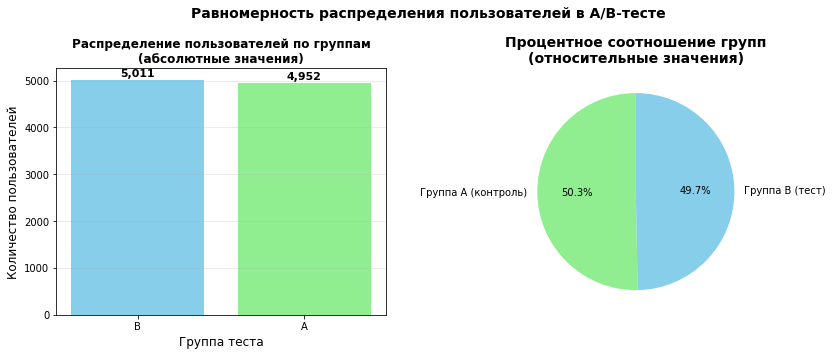

In [52]:
# Данные для графиков
group_counts = clean_interface_participants['group'].value_counts()
group_percentages = clean_interface_participants['group'].value_counts(normalize=True) * 100

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Столбчатая диаграмма (абсолютные значения)
bars = ax1.bar(group_counts.index, group_counts.values, color=['skyblue', 'lightgreen'])
ax1.set_title('Распределение пользователей по группам\n(абсолютные значения)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Группа теста', fontsize=12)
ax1.set_ylabel('Количество пользователей', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, count in zip(bars, group_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 30,
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Круговая диаграмма (процентное соотношение)
ax2.pie(group_percentages.values, 
        labels=['Группа A (контроль)', 'Группа B (тест)'],
        colors=['lightgreen', 'skyblue'],
        autopct='%1.1f%%',
        startangle=90)

ax2.set_title('Процентное соотношение групп\n(относительные значения)', fontsize=14, fontweight='bold')


# Добавляем общий заголовок
total_users = len(clean_interface_participants)
fig.suptitle(f'Равномерность распределения пользователей в A/B-тесте', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Итак, мы исключили пользователей, участвовавших в двух разных тестах из анализа, получив "чистую" выборку из 9963 пользователей. После очистки распределение осталось почти идеально равномерным: Группа A (контроль): 4952 (49.7%), Группа B (тест): 5011 (50.3%). Это отличный результат, нет перекоса в размерах групп. Таким образом мы исправили ключевое нарушение в проведении теста, теперь у нас есть изолированные группы для сравнения, что делает дальнейший анализ корректным.

Еще нужно проверить очищенную выборку на внутренние дубликаты (случаи, когда один и тот же пользователь встречается внутри теста interface_eu_test несколько раз). Пользователь обязательно должен находиться только в одной экспериментальной группе (A или B). Если дубликаты обнаружатся, таких пользователей также нужно будет исключить из анализа для обеспечения чистоты результатов.

In [53]:
# Ищем дубликаты user_id в уже очищенной выборке
duplicates_in_clean = clean_interface_participants[clean_interface_participants.duplicated(subset=['user_id'], keep=False)]

# Анализируем, что мы нашли
num_duplicate_users = duplicates_in_clean['user_id'].nunique()
num_duplicate_rows = len(duplicates_in_clean)

print(f"Найдено пользователей с дубликатами: {num_duplicate_users}")
print(f"Всего дублированных строк: {num_duplicate_rows}")

Найдено пользователей с дубликатами: 0
Всего дублированных строк: 0


Отлично, дубликатов внутри теста не обнаружено. Для упрощения кода в последующих этапах анализа переименуем нашу очищенную таблицу обратно в participants.

In [54]:
# Переименовываем очищенную таблицу
participants = clean_interface_participants.copy()

Посмотрим данные об очищенной таблице

In [55]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
7,0031F1B5E9FBF708,A,interface_eu_test,Android


In [56]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9963 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  9963 non-null   object
 1   group    9963 non-null   object
 2   ab_test  9963 non-null   object
 3   device   9963 non-null   object
dtypes: object(4)
memory usage: 389.2+ KB


Данные пользователей подготовлены для чистого анализа. Мы проверили, что тест соответствует техническому заданию: анализируем именно interface_eu_test с контрольной группой A и тестовой группой B. Распределение пользователей почти идеальное (49.7% в группе A и 50.3% в группе B), при этом исключили 887 человек (8%), участвовавших одновременно в другом тесте, что гарантирует чистоту эксперимента. Таким образом, выборка готова для оценки результатов A/B-теста.

Осталось только проверить временные рамки теста: убедиться, что все пользователи зарегистрировались в период его проведения и что тест длился минимум 7 дней. Это мы сделаем при анализе данных событий.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

Сначала объеденим таблицы. Будем использовать INNER JOIN: так мы автоматически получим только те события, которые есть у пользователей нашего теста.

In [57]:
# Соединим таблицу событий с информацией о пользователях теста

print(f"Размер таблицы events (события всех пользователей): {len(events)}")
print(f"Размер таблицы participants (пользователи теста): {len(participants)}")

# Делаем INNER JOIN по user_id
events_with_groups = events.merge(
    participants[['user_id', 'group', 'device']],
    on='user_id',
    how='inner'
)

print(f"\nРазмер таблицы events_with_groups (события только пользователей теста): {len(events_with_groups)}")
print(f"Уникальных пользователей после соединения: {events_with_groups['user_id'].nunique()}")

Размер таблицы events (события всех пользователей): 690131
Размер таблицы participants (пользователи теста): 9963

Размер таблицы events_with_groups (события только пользователей теста): 67582
Уникальных пользователей после соединения: 9963


Проверим, что получилось

In [58]:
events_with_groups.head()

,user_id,event_dt,event_name,details,cost,group,device
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,0.0,A,iPhone
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,NaN,A,iPhone
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,NaN,A,iPhone
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,NaN,A,iPhone
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,NaN,A,iPhone


Таблицы успешно соединены с помощью INNER JOIN. Теперь все 67582 события принадлежат исключительно 9963 пользователям нашего A/B-теста. К каждому событию добавлена информация о группе теста (A или B) и типе устройства пользователя, что обеспечивает полную связность данных для анализа.

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации.

По заданию мы проверяем гипотезу: "в течение семи дней после регистрации конверсия увеличится". Значит, все события после 7 дней нас не интересуют, они выходят за рамки гипотезы. Значит, нам нужно найти время регистрации каждого пользователя, затем для каждого события рассчитать, сколько дней прошло с момента регистрации (лайфтайм) и оставить только события, произошедшие в первые 7 дней после регистрации. Приступим.

Сначала создадим таблицу с временем регистрации для каждого пользователя.

In [59]:
# Выделяем события регистрации для всех пользователей теста
registration_events = events_with_groups[events_with_groups['event_name'] == 'registration'].copy()

# Оставляем только нужные столбцы: user_id и время регистрации
registration_times = registration_events[['user_id', 'event_dt']].copy()
registration_times.rename(columns={'event_dt': 'registration_time'}, inplace=True)

print(f"Найдено {len(registration_times)} событий регистрации")
print(f"Уникальных пользователей с регистрацией: {registration_times['user_id'].nunique()}")

# Проверяем, что у каждого пользователя только одна регистрация
duplicate_registrations = registration_times[registration_times.duplicated(subset=['user_id'], keep=False)]
print(f"Пользователей с несколькими регистрациями: {len(duplicate_registrations)}")

registration_times.head()

Найдено 9963 событий регистрации
Уникальных пользователей с регистрацией: 9963
Пользователей с несколькими регистрациями: 0


,user_id,registration_time
0,5F506CEBEDC05D30,2020-12-06 14:10:01
6,51278A006E918D97,2020-12-06 14:37:25
11,A0C1E8EFAD874D8B,2020-12-06 17:20:22
14,275A8D6254ACF530,2020-12-06 19:36:54
28,0B704EB2DC7FCA4B,2020-12-06 19:42:20


Тут все хорошо, у каждого юзера есть регистрация и она только одна, столбец с датой регистрации создан. Теперь добавим время регистрации к каждому событию пользователя.

In [60]:
# Соединяем все события с временем регистрации
events_with_reg_time = events_with_groups.merge(
    registration_times,
    on='user_id',
    how='left'
)

print(f"Размер таблицы после добавления времени регистрации: {len(events_with_reg_time)}")
print(f"Событий без времени регистрации: {events_with_reg_time['registration_time'].isna().sum()}")

# Проверяем результат
events_with_reg_time[['user_id', 'event_dt', 'registration_time', 'event_name']].head(10)

Размер таблицы после добавления времени регистрации: 67582
Событий без времени регистрации: 0


,user_id,event_dt,registration_time,event_name
0,5F506CEBEDC05D30,2020-12-06 14:10:01,2020-12-06 14:10:01,registration
1,5F506CEBEDC05D30,2020-12-07 01:25:14,2020-12-06 14:10:01,login
2,5F506CEBEDC05D30,2020-12-07 01:25:47,2020-12-06 14:10:01,login
3,5F506CEBEDC05D30,2020-12-09 12:40:49,2020-12-06 14:10:01,login
4,5F506CEBEDC05D30,2020-12-09 12:40:49,2020-12-06 14:10:01,product_page
5,5F506CEBEDC05D30,2020-12-10 23:18:00,2020-12-06 14:10:01,product_page
6,51278A006E918D97,2020-12-06 14:37:25,2020-12-06 14:37:25,registration
7,51278A006E918D97,2020-12-07 01:49:18,2020-12-06 14:37:25,login
8,51278A006E918D97,2020-12-07 01:49:19,2020-12-06 14:37:25,login
9,51278A006E918D97,2020-12-09 02:12:06,2020-12-06 14:37:25,product_cart


Тоже выглядит хорошо. Теперь для каждого события считаем, сколько дней прошло с момента регистрации.

In [61]:
# Рассчитываем разницу во времени между событием и регистрацией (в днях)
events_with_reg_time['days_after_registration'] = (
    events_with_reg_time['event_dt'] - events_with_reg_time['registration_time']
).dt.total_seconds() / (24 * 3600)  # переводим секунды в дни

# Проверяем результат
events_with_reg_time[['user_id', 'event_dt', 'registration_time', 
                      'days_after_registration', 'event_name']].head(10)

,user_id,event_dt,registration_time,days_after_registration,event_name
0,5F506CEBEDC05D30,2020-12-06 14:10:01,2020-12-06 14:10:01,0.000000,registration
1,5F506CEBEDC05D30,2020-12-07 01:25:14,2020-12-06 14:10:01,0.468900,login
2,5F506CEBEDC05D30,2020-12-07 01:25:47,2020-12-06 14:10:01,0.469282,login
3,5F506CEBEDC05D30,2020-12-09 12:40:49,2020-12-06 14:10:01,2.938056,login
4,5F506CEBEDC05D30,2020-12-09 12:40:49,2020-12-06 14:10:01,2.938056,product_page
5,5F506CEBEDC05D30,2020-12-10 23:18:00,2020-12-06 14:10:01,4.380544,product_page
6,51278A006E918D97,2020-12-06 14:37:25,2020-12-06 14:37:25,0.000000,registration
7,51278A006E918D97,2020-12-07 01:49:18,2020-12-06 14:37:25,0.466586,login
8,51278A006E918D97,2020-12-07 01:49:19,2020-12-06 14:37:25,0.466597,login
9,51278A006E918D97,2020-12-09 02:12:06,2020-12-06 14:37:25,2.482419,product_cart


Теперь фильтруем события, оставляя только те, что произошли в первые 7 дней после регистрации (включительно).

In [62]:
# Создаем копию на всякий случай
events_7days = events_with_reg_time.copy()

# Фильтруем события: оставляем только первые 7 дней после регистрации
# Помним, что день регистрации = 0 дней
events_7days_filtered = events_7days[events_7days['days_after_registration'] <= 7].copy()

print(f"Всего событий до фильтрации: {len(events_7days)}")
print(f"Событий за первые 7 дней: {len(events_7days_filtered)}")
print(f"Процент событий в первых 7 днях: {len(events_7days_filtered)/len(events_7days)*100:.1f}%")

Всего событий до фильтрации: 67582
Событий за первые 7 дней: 58411
Процент событий в первых 7 днях: 86.4%


Убедимся, что после фильтрации у нас остались все пользователи теста.

In [63]:
# Проверяем количество уникальных пользователей после фильтрации
users_after_filter = events_7days_filtered['user_id'].nunique()
print(f"Уникальных пользователей после фильтрации (первые 7 дней): {users_after_filter}")
print(f"Всего пользователей в тесте: {len(participants)}")
print(f"Пользователей без событий в первые 7 дней: {len(participants) - users_after_filter}")

Уникальных пользователей после фильтрации (первые 7 дней): 9963
Всего пользователей в тесте: 9963
Пользователей без событий в первые 7 дней: 0


Все ок, теперь у нас есть данные, готовые для анализа конверсии в первые 7 дней.

In [64]:
# Создаем финальную таблицу для анализа
events_data = events_7days_filtered.copy()

Посмотрим данные об этой финальной таблице events_data

In [65]:
# Посмотрим информацию о финальной таблице
events_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 58411 entries, 0 to 67581
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  58411 non-null  object        
 1   event_dt                 58411 non-null  datetime64[ns]
 2   event_name               58411 non-null  object        
 3   details                  15519 non-null  object        
 4   cost                     15519 non-null  float64       
 5   group                    58411 non-null  object        
 6   device                   58411 non-null  object        
 7   registration_time        58411 non-null  datetime64[ns]
 8   days_after_registration  58411 non-null  float64       
dtypes: datetime64[ns](2), float64(2), object(5)
memory usage: 4.5+ MB


In [66]:
# Посмотрим структуру финальной таблицы
events_data.head()

,user_id,event_dt,event_name,details,cost,group,device,registration_time,days_after_registration
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,0.0,A,iPhone,2020-12-06 14:10:01,0.000000
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,NaN,A,iPhone,2020-12-06 14:10:01,0.468900
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,NaN,A,iPhone,2020-12-06 14:10:01,0.469282
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,NaN,A,iPhone,2020-12-06 14:10:01,2.938056
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,NaN,A,iPhone,2020-12-06 14:10:01,2.938056


Еще мы должны убедиться, что после всех фильтраций и ограничения по 7 дням распределение осталось равномерным.

In [67]:
# Проверяем уникальных пользователей по группам
print("\nРаспределение уникальных пользователей по группам в events_data:")
users_per_group = events_data.groupby('group')['user_id'].nunique()
users_percentage = users_per_group / users_per_group.sum() * 100

print(users_per_group)
print(f"\nПроцентное соотношение пользователей по группам:")
print(users_percentage.round(2))


Распределение уникальных пользователей по группам в events_data:
group
A    4952
B    5011
Name: user_id, dtype: int64

Процентное соотношение пользователей по группам:
group
A    49.7
B    50.3
Name: user_id, dtype: float64


Визуализируем это для наглядности

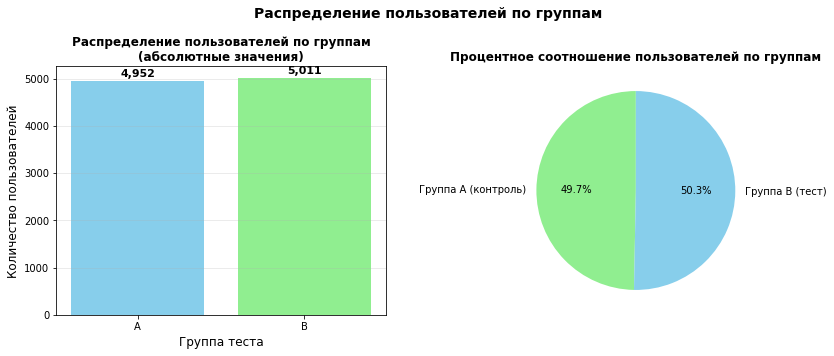

In [68]:
# Создаем графики для распределения пользователей
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Столбчатая диаграмма пользователи по группам (абсолютные значения)
bars2 = ax1.bar(users_per_group.index, users_per_group.values, 
                color=['skyblue', 'lightgreen'])
ax1.set_title('Распределение пользователей по группам\n(абсолютные значения)', 
             fontsize=12, fontweight='bold')
ax1.set_xlabel('Группа теста', fontsize=12)
ax1.set_ylabel('Количество пользователей', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, count in zip(bars2, users_per_group.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{count:,}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

# Круговая диаграмма пользователи по группам (процентное соотношение)
ax2.pie(users_percentage.values, 
        labels=['Группа A (контроль)', 'Группа B (тест)'],
        colors=['lightgreen', 'skyblue'],
        autopct='%1.1f%%',
        startangle=90)
ax2.set_title('Процентное соотношение пользователей по группам', 
             fontsize=12, fontweight='bold')

# Общий заголовок для обоих графиков
total_users = events_data['user_id'].nunique()
fig.suptitle(f'Распределение пользователей по группам', 
            fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Мы собрали 58411 событий от 9963 пользователей A/B-теста, произошедших в первые 7 дней после регистрации. Распределение пользователей между группами осталось практически идеальным: 49.7% в контрольной группе A (4952 пользователя) и 50.3% в тестовой группе B (5011 пользователей), что обеспечивает корректность дальнейшего анализа. Все 9963 пользователя имеют хотя бы одно событие в этот период, а 86.4% всех событий попало в заданный 7-дневный горизонт анализа. Теперь данные готовы для оценки конверсии в покупателей.

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

Теперь переходим к оценке достаточности выборки. Это важный этап, чтобы понять, можно ли доверять результатам нашего A/B-теста.

Рассчитываем, сколько пользователей нужно в каждой группе, чтобы обнаружить увеличение конверсии на 3 процентных пункта с заданной достоверностью (95%) и мощностью (80%)

In [69]:
# Импортируем необходимые функции
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

# Задаём параметры из технического задания
alpha = 0.05  # Уровень значимости
beta = 0.2    # Ошибка второго рода
power = 1 - beta  # Мощность теста = 0.8 
p = 0.3       # Базовый уровень конверсии 
mde = 0.03    # Минимальный детектируемый эффект (3 процентных пункта)

# Рассчитываем размер эффекта
effect_size = proportion_effectsize(p, p + mde)
print(f"\nРазмер эффекта: {effect_size:.4f}")

# Инициализируем класс для анализа мощности
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  # Равномерное распределение выборок (1:1)
)

# Округляем до целого числа
required_sample_size = int(np.ceil(sample_size_per_group))
total_required = required_sample_size * 2

print(f"Минимальный размер выборки для каждой группы: {required_sample_size:,}")
print(f"Общий минимальный размер выборки: {total_required:,}")


Размер эффекта: -0.0646
Минимальный размер выборки для каждой группы: 3,762
Общий минимальный размер выборки: 7,524


Согласно расчетам, для обнаружения прироста конверсии на 3 процентных пункта с достоверностью 95% и мощностью 80% требуется минимум 3762 пользователя в каждой группе. У нас в тесте участвует значительно больше: 4952 пользователя в группе A и 5011 в группе B, что почти на 1200 человек превышает минимальные требования в каждой группе.

Это означает, что наша выборка из 9963 пользователей более чем достаточна для проведения A/B-теста. Мы можем быть уверены, что если новый интерфейс действительно увеличивает конверсию на 3 процентных пункта или больше, мы с высокой вероятностью (80%) это обнаружим. Более того, при текущем размере выборки мы потенциально можем обнаруживать и более мелкие изменения конверсии, чем заявленные 3 процентных пункта.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

Теперь нужно рассчитать ключевые метрики для A/B-теста: количество покупателей и общее количество посетителей в каждой группе. Это основа для расчета конверсии.

In [70]:
# Находим всех пользователей, которые совершили покупку (purchase) в первые 7 дней
purchase_events = events_data[events_data['event_name'] == 'purchase'].copy()

print(f"Всего покупок в первые 7 дней: {len(purchase_events)}")
print(f"Уникальных покупателей в первые 7 дней: {purchase_events['user_id'].nunique()}")

Всего покупок в первые 7 дней: 5556
Уникальных покупателей в первые 7 дней: 2857


Рассчитываем общее количество пользователей по группам

In [71]:
# Общее количество пользователей по группам
total_visitors_by_group = participants.groupby('group')['user_id'].nunique()

print("\nОбщее количество посетителей по группам:")
print(total_visitors_by_group)


Общее количество посетителей по группам:
group
A    4952
B    5011
Name: user_id, dtype: int64


Рассчитываем количество покупателей по группам

In [72]:
# Получаем уникальных покупателей по группам
buyers_by_group = purchase_events.groupby('group')['user_id'].nunique()

print("Количество покупателей по группам:")
print(buyers_by_group)


Количество покупателей по группам:
group
A    1377
B    1480
Name: user_id, dtype: int64


Рассчитываем конверсию (сейчас это просто "сырые" цифры, они показывают разницу, но не говорят, значимая ли она).

In [73]:
# Рассчитываем конверсию
conversion_by_group = buyers_by_group / total_visitors_by_group

print("Конверсия по группам:")
for group in ['A', 'B']:
    buyers = buyers_by_group.get(group, 0)
    total = total_visitors_by_group.get(group, 0)
    conv = buyers / total if total > 0 else 0
    print(f"Группа {group}: {buyers} / {total} = {conv:.3f} ({conv*100:.1f}%)")

Конверсия по группам:
Группа A: 1377 / 4952 = 0.278 (27.8%)
Группа B: 1480 / 5011 = 0.295 (29.5%)


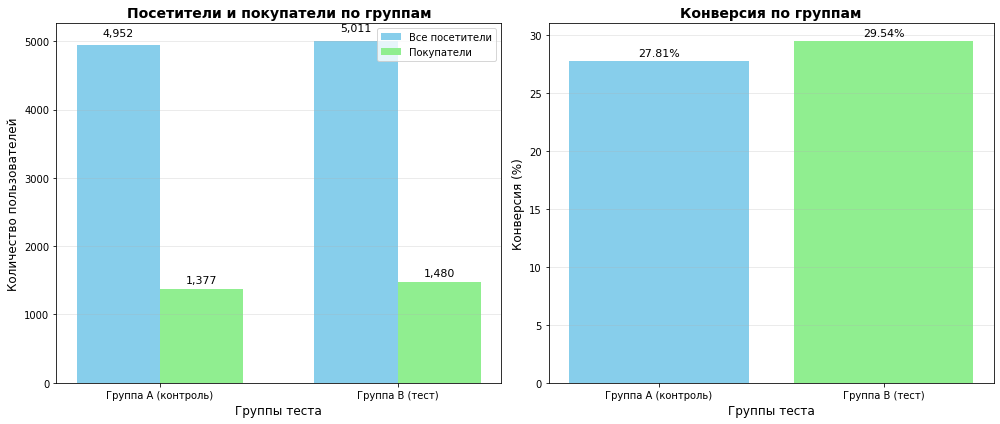

In [74]:
# Визуализация: посетители и покупатели по группам (обновленная версия)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Количество посетителей и покупателей по группам
group_labels = ['Группа A (контроль)', 'Группа B (тест)']
visitor_counts = [total_visitors_by_group.get('A', 0), total_visitors_by_group.get('B', 0)]
buyer_counts = [buyers_by_group.get('A', 0), buyers_by_group.get('B', 0)]

x = np.arange(len(group_labels))
width = 0.35

# Меняем порядок: сначала посетители, потом покупатели
bars1 = ax1.bar(x - width/2, visitor_counts, width, label='Все посетители', color='skyblue')
bars2 = ax1.bar(x + width/2, buyer_counts, width, label='Покупатели', color='lightgreen')

ax1.set_xlabel('Группы теста', fontsize=12)
ax1.set_ylabel('Количество пользователей', fontsize=12)
ax1.set_title('Посетители и покупатели по группам', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(group_labels)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{int(height):,}', ha='center', va='bottom', fontsize=11)

for bar in bars2:
    height = bar.get_height()
    if height > 0:  # Не показываем 0, если покупателей нет
        ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
                f'{int(height):,}', ha='center', va='bottom', fontsize=11)

# 2. Конверсия по группам
conversion_values = [conversion_by_group.get('A', 0)*100, conversion_by_group.get('B', 0)*100]

bars3 = ax2.bar(group_labels, conversion_values, color=['skyblue', 'lightgreen'])
ax2.set_xlabel('Группы теста', fontsize=12)
ax2.set_ylabel('Конверсия (%)', fontsize=12)
ax2.set_title('Конверсия по группам', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, conv in zip(bars3, conversion_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{conv:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Данные показывают, что тестовая группа B с новым интерфейсом демонстрирует более высокую конверсию: 29.5% против 27.8% в контрольной группе A. Разница составляет 1.7 процентных пункта, и это заметно меньше целевых 3 процентных пунктов, заявленных в гипотезе.

Тестовая группа B привлекла 1480 покупателей из 5011 посетителей, тогда как контрольная группа A привлекла 1377 покупателей из 4952 посетителей. Хотя разница в конверсии есть, необходимо проверить ее статистическую значимость, чтобы понять, вызвана ли она действительно новым интерфейсом или является случайным отклонением.

Рассчитываем абсолютное и относительное изменение конверсии между группами. Это поможет понять не только "есть ли разница", но и "насколько она значима" с точки зрения бизнеса. Абсолютный прирост в процентных пунктах показывает фактическую разницу, а относительный рост в процентах помогает оценить масштаб эффекта.

In [75]:
# Рассчитываем абсолютное и относительное изменение конверсии

# Конверсии по группам
conv_a = conversion_by_group.get('A', 0)
conv_b = conversion_by_group.get('B', 0)

# Абсолютное изменение (в процентных пунктах)
absolute_change = conv_b - conv_a
absolute_change_pp = absolute_change * 100  # переводим в проценты

# Относительное изменение (в процентах)
relative_change = ((conv_b - conv_a) / conv_a) * 100

print(f"Конверсия контрольной группы A: {conv_a:.3f} ({conv_a*100:.1f}%)")
print(f"Конверсия тестовой B Ф: {conv_b:.3f} ({conv_b*100:.1f}%)")
print()
print(f"Абсолютное изменение (B - A): {absolute_change_pp:.2f} процентных пункта")
print(f"Относительное изменение: {relative_change:.1f}% улучшения")

Конверсия контрольной группы A: 0.278 (27.8%)
Конверсия тестовой B Ф: 0.295 (29.5%)

Абсолютное изменение (B - A): 1.73 процентных пункта
Относительное изменение: 6.2% улучшения


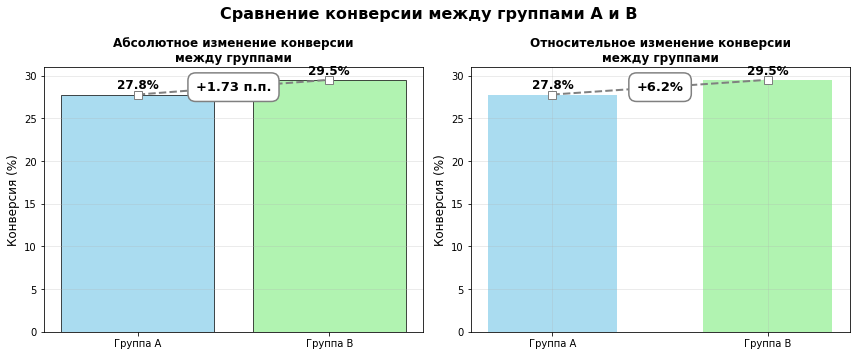

In [76]:
# Создаем один график с двумя визуализациями
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График 1: абсолютное изменение конверсии в процентных пунктах
# Данные для графика
groups = ['Группа A', 'Группа B']
conversions = [conv_a * 100, conv_b * 100]
colors = ['skyblue', 'lightgreen']

# Строим столбчатую диаграмму
bars1 = ax1.bar(groups, conversions, color=colors, alpha=0.7, edgecolor='black')

# Добавляем пунктирную линию улучшения
ax1.plot(groups, conversions, 's--', color='gray', linewidth=2, markersize=8, markerfacecolor='white')

# Добавляем абсолютное улучшение в табличке
mid_x = 0.5
mid_y = (conversions[0] + conversions[1]) / 2
absolute_improvement_text = f'+{absolute_change_pp:.2f} п.п.'

ax1.text(mid_x, mid_y, absolute_improvement_text, 
         ha='center', va='center', fontsize=13, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor='gray', linewidth=1.5))

# Добавляем подписи значений
for i, conv in enumerate(conversions):
    ax1.text(i, conv + 0.3, f'{conv:.1f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Настройки графика
ax1.set_ylabel('Конверсия (%)', fontsize=12)
ax1.set_title('Абсолютное изменение конверсии\nмежду группами', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# График 2: относительное изменение конверсии в процентах
x_pos = [0, 1]

# Строим столбчатую диаграмму
bars2 = ax2.bar(x_pos, conversions, color=['skyblue', 'lightgreen'], alpha=0.7, width=0.6)

# Добавляем пунктирную линию улучшения
ax2.plot(x_pos, conversions, 's--', color='gray', linewidth=2, markersize=8, markerfacecolor='white')

# Добавляем относительное улучшение в табличке
relative_improvement_text = f'+{relative_change:.1f}%'

ax2.text(mid_x, mid_y, relative_improvement_text, 
         ha='center', va='center', fontsize=13, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor='gray', linewidth=1.5))

ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Группа A', 'Группа B'])
ax2.set_ylabel('Конверсия (%)', fontsize=12)
ax2.set_title('Относительное изменение конверсии\nмежду группами', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Добавляем значения конверсии над столбцами
for i, val in enumerate(conversions):
    ax2.text(i, val + 0.3, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Общий заголовок
plt.suptitle('Сравнение конверсии между группами A и B', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Проведем оценку результатов A/B-тестирования:

Мы анализируем классический A/B-тест с бинарным исходом: пользователь либо совершил покупку в первые 7 дней, либо нет. В нашем случае это сравнение двух независимых пропорций: конверсии в контрольной группе A (27.8%) и тестовой группе B (29.5%).

Для такого сравнения лучше всего подходит **z-тест для пропорций**. Это стандартный статистический метод (у нас большие и независимые выборки: 4952 человека в группе A и 5011 в группе B). Обе выборки удовлетворяют ключевому условию применения z-теста: в каждой группе достаточно много как успешных исходов (покупок), так и неуспешных.

Гипотезы:

H₀ (нулевая): Конверсия в группе B НЕ больше, чем в группе A (p_B ≤ p_A)

H₁ (альтернативная): Конверсия в группе БОЛЬШЕ (p_B > p_A)

Мы проверяем гипотезу о том, что новый интерфейс в группе B улучшает конверсию по сравнению со старым в группе A. Статистически это означает, что мы хотим доказать, что доля покупок в группе B больше, чем в группе A.

Будем использовать параметр alternative='smaller', потому что он проверяет, меньше ли первая пропорция по сравнению со второй. Мы передали на первое место конверсию группы A, а на второе конверсию группы B. Таким образом, alternative='smaller' проверяет именно нашу гипотезу: A < B, то есть конверсия в группе с новым интерфейсом выше.

In [77]:
# Импортируем функцию для z-теста
from statsmodels.stats.proportion import proportions_ztest

# Данные для теста: покупатели и посетители по группам
count = [buyers_by_group['A'], buyers_by_group['B']]  # покупатели в группах A, B
nobs = [total_visitors_by_group['A'], total_visitors_by_group['B']]  # всего посетителей

# Проводим односторонний z-тест: проверяем, что B лучше A
# alternative='smaller' проверяет, что первая группа (A) меньше второй (B)
z_stat, p_value = proportions_ztest(count, nobs, alternative='smaller')

print(f"P-value: {p_value:.4f}")
print(f"Уровень значимости α: 0.05")

# Проверяем статистическую значимость
if p_value < 0.05:
    print(f"\nP-value ({p_value:.6f}) < α (0.05)")
    print("Отвергаем нулевую гипотезу: конверсия в группе B статистически значимо выше, чем в группе A")
else:
    print(f"P-value ({p_value:.6f}) ≥ α (0.05)")
    print("Не отвергаем нулевую гипотезу: нет статистически значимых доказательств, что конверсия в группе B выше")

P-value: 0.0283
Уровень значимости α: 0.05

P-value (0.028263) < α (0.05)
Отвергаем нулевую гипотезу: конверсия в группе B статистически значимо выше, чем в группе A


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

Статистический анализ показывает, что конверсия в группе B (новый интерфейс) статистически значимо выше, чем в группе A (старый интерфейс). P-value составляет 0.0283, что меньше порога значимости 0.05. Это означает, что вероятность получить такую разницу случайно составляет всего 2.8%.

Однако ожидаемый эффект не достигнут. Нашим целевым показателем было увеличение конверсии на 3 процентных пункта, при этом фактический результат - это увеличение на 1.7 процентных пункта (с 27.8% до 29.5%), относительное улучшение +6.2%.

# **Итоговый вывод**

Новый интерфейс сайта демонстрирует положительный эффект на конверсию, но с существенным отставанием от запланированных показателей. Увеличение на 1.7 процентных пункта является статистически значимым, но не достигает целевых 3 процентных пунктов, заложенных в гипотезе. Это означает, что упрощение интерфейса действительно помогает пользователям, однако ожидаемого прорыва в конверсии не произошло и результат оказался скромнее прогнозируемого почти вдвое.


**Рекомендации для бизнеса**:

Отложить массовое внедрение, т.к. текущее улучшение недостаточно велико для оправдания затрат на полномасштабный переход.

Провести углубленный анализ:
- Изучить поведенческие метрики: время до покупки, глубина воронки, отказы на ключевых шагах
- Проанализировать сегменты пользователей: возможно, интерфейс лучше работает на определенных устройствах или для конкретных категорий товаров
- Проверить другие способы упрощения покупки и улучшения пользовательского опыта (например, убрать дополнительные шаги при оформлении заказа (слишком длинная форма), сделать более заметными кнопки "Купить" или "Добавить в корзину", упростить процесс выбора товара (слишком много фильтров и опций), добавить быструю покупку в один клик для популярных товаров, улучшить мобильную версию сайта (возможно, на телефонах сложнее покупать)).
- Оценить экономику проекта: рассчитать ROI от 6.1% улучшения конверсии и сравнить с затратами на доработку и внедрение нового интерфейса.

Альтернативный подход: если бизнес готов принять постепенное улучшение, можно начать поэтапное внедрение, одновременно работая над следующими итерациями улучшений. В этом случае стоит установить KPI мониторинга на уровне 1.7-2.0 п.п. и планировать дальнейшие оптимизации.